# Prediksi Kurs USD/IDR dengan LSTM + Attention

Notebook ini memprediksi nilai tukar **USD/IDR 7 hari ke depan** menggunakan model **LSTM + Multi-Head Attention**.

**Alur singkat:**
- **Data** — harga historis USD/IDR (Yahoo Finance) + indikator fundamental (DXY, VIX, Brent, IHSG, US 10Y Yield, CPO, suku bunga BI & Fed, inflasi).
- **Fitur** — 22 fitur (9 teknikal + 13 fundamental); fitur fundamental digeser 1 hari untuk mencegah *lookahead*.
- **Validasi** — *Walk-Forward Validation* + *Theil's U* (model dibandingkan dengan *random walk*).
- **Output** — proyeksi 7 hari + *confidence interval* lewat *Monte Carlo Dropout*.

> ⚠️ Proyeksi berbasis pola historis — **bukan rekomendasi finansial**.

## 1. Setup, Data & Visualisasi

Impor library, set konstanta, lalu unduh data: harga USD/IDR beserta indikator fundamental. Diakhiri plot tren historis kurs.

In [11]:
# Cell 1 — Setup dan data
# Import library, atur konstanta, dan download data sumber
import os
import warnings
# yfinance & pandas memunculkan FutureWarning/UserWarning yang berisik; warning lain tetap tampil
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from datetime import datetime, timedelta

from sklearn.preprocessing import MaxAbsScaler

import tensorflow as tf  # type: ignore
from tensorflow.keras.layers import LSTM, Dense, Dropout  # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau  # type: ignore
from tensorflow.keras.regularizers import l2  # type: ignore

# Reproducibility — agar hasil konsisten tiap kali di-run
np.random.seed(42)
tf.random.set_seed(42)   # harus di sini, sebelum Walk-Forward Cell 4

# Konstanta global
START         = '2001-06-28'
END           = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
WINDOW     = 30
HORIZON    = 7
SKIP       = 30
MC_SAMPLES = 500

# Path output
RUN_TS       = datetime.now().strftime('%Y%m%d_%H%M%S')
NOTEBOOK_DIR = os.getcwd()
RESULT_DIR   = os.path.join(NOTEBOOK_DIR, 'Result', RUN_TS)
os.makedirs(RESULT_DIR, exist_ok=True)
print(f"Output folder: {RESULT_DIR}")

# Download data utama USDIDR=X
df = yf.download('USDIDR=X', start=START, end=END, progress=False)
df.columns  = df.columns.droplevel(1)
df['Close'] = df['Close'].ffill()
df['High']  = df['High'].ffill()
df['Low']   = df['Low'].ffill()
print(f"Rentang       : {df.index[0].date()} s.d. {df.index[-1].date()}")
print(f"Total rows    : {len(df)}")
print(f"Close terakhir: {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})")

# Helper: download return harian dari yfinance
def _yf_return(ticker, name, start, end, add_lag=False):
    """Download close, hitung pct_change return harian; opsional tambah lag_1."""
    try:
        raw = yf.download(ticker, start=start, end=end, progress=False)
        if raw.empty:
            raise ValueError("data kosong")
        raw.columns = raw.columns.droplevel(1)
        ret = raw['Close'].pct_change().rename(f'{name}_return')
        out = pd.DataFrame(ret)
        if add_lag:
            out[f'{name}_lag1'] = ret.shift(1)
        return out
    except Exception as e:
        print(f"WARNING: Gagal download {ticker} ({name}): {e}")
        return None

# --- Indikator pasar global ---
dxy_df   = _yf_return('DX-Y.NYB', 'dxy',   START, END, add_lag=True)
vix_df   = _yf_return('^VIX',     'vix',   START, END, add_lag=True)
brent_df = _yf_return('BZ=F',     'brent', START, END, add_lag=False)
ihsg_df  = _yf_return('^JKSE',    'ihsg',  START, END, add_lag=False)
# US 10Y Treasury Yield: yield naik → USD menguat → IDR melemah
tnx_df   = _yf_return('^TNX',     'tnx',   START, END, add_lag=False)
# CPO (Palm Oil): Indonesia eksportir terbesar; harga naik → devisa masuk → IDR menguat
cpo_df   = _yf_return('KCE=F',    'cpo',   START, END, add_lag=False)

# Helper: download series FRED via direct URL
# Ambil data FRED tanpa perlu API key, lalu resample ke frekuensi harian.

def _fred_daily(series_id, col_name, start, end, mom_pct=False):
    """Download seri FRED bulanan, ubah ke data harian, lalu isi nilai kosong.
    mom_pct=True: hitung persentase perubahan bulanan sebelum resample.
    """
    try:
        import requests, io
        url  = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        raw  = pd.read_csv(io.StringIO(resp.text), index_col=0, parse_dates=True)
        raw.columns = [col_name]
        # FRED pakai '.' untuk nilai kosong
        raw  = raw[raw[col_name] != '.'].copy()
        raw[col_name] = raw[col_name].astype(float)
        raw  = raw[raw.index >= pd.Timestamp(start)]
        if mom_pct:
            raw = raw.pct_change().fillna(0)
        daily_idx = pd.date_range(start=raw.index.min(),
                                  end=pd.Timestamp(end), freq='D')
        return raw.reindex(daily_idx).ffill().fillna(0.0)
    except Exception as e:
        print(f'WARNING: Gagal download FRED {series_id}: {e}. Diisi nol.')
        idx = pd.date_range(start=start, end=end, freq='D')
        return pd.DataFrame({col_name: 0.0}, index=idx)

bi_rate_df  = _fred_daily('IR3TIB01IDM156N', 'bi_rate',  START, END)
fed_rate_df = _fred_daily('FEDFUNDS',         'fed_rate', START, END)
us_cpi_df   = _fred_daily('CPIAUCSL',          'us_cpi',  START, END, mom_pct=True)
id_cpi_df   = _fred_daily('IDNCPIALLMINMEI',   'id_cpi',  START, END, mom_pct=True)

# Rate spread = BI Rate - Fed Rate
_bi  = bi_rate_df['bi_rate'].reindex(df.index).ffill().fillna(0.0)
_fed = fed_rate_df['fed_rate'].reindex(df.index).ffill().fillna(0.0)
df['rate_spread'] = (_bi - _fed).values

# Merge semua ke df
for _fdf in [dxy_df, vix_df, brent_df, ihsg_df, tnx_df, cpo_df,
             bi_rate_df, fed_rate_df, us_cpi_df, id_cpi_df]:
    if _fdf is not None:
        for _col in _fdf.columns:
            df[_col] = _fdf[_col].reindex(df.index).ffill().fillna(0.0)

# Pastikan semua kolom fundamental ada; isi 0 jika download gagal
_FUND_COLS = [
    'dxy_return', 'dxy_lag1',
    'vix_return', 'vix_lag1',
    'brent_return', 'ihsg_return',
    'tnx_return',                   # US 10Y Treasury Yield return
    'cpo_return',                   # CPO / Palm Oil return
    'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread',
]
for _c in _FUND_COLS:
    if _c not in df.columns:
        print(f"WARNING: {_c} tidak tersedia, diisi 0.")
        df[_c] = 0.0
    df[_c] = df[_c].fillna(0.0)

print(f"\nFitur fundamental tersedia : {_FUND_COLS}")
print(f"Shape df setelah merge     : {df.shape}")

Output folder: /home/hubbard/sentiment-analysis-lstm/Result/20260530_145935
Rentang       : 2001-06-28 s.d. 2026-05-29
Total rows    : 6290
Close terakhir: 17,878.00 IDR  (2026-05-29)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: KCE=F"}}}
$KCE=F: possibly delisted; no timezone found

1 Failed download:
['KCE=F']: possibly delisted; no timezone found



Fitur fundamental tersedia : ['dxy_return', 'dxy_lag1', 'vix_return', 'vix_lag1', 'brent_return', 'ihsg_return', 'tnx_return', 'cpo_return', 'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread']
Shape df setelah merge     : (6290, 18)


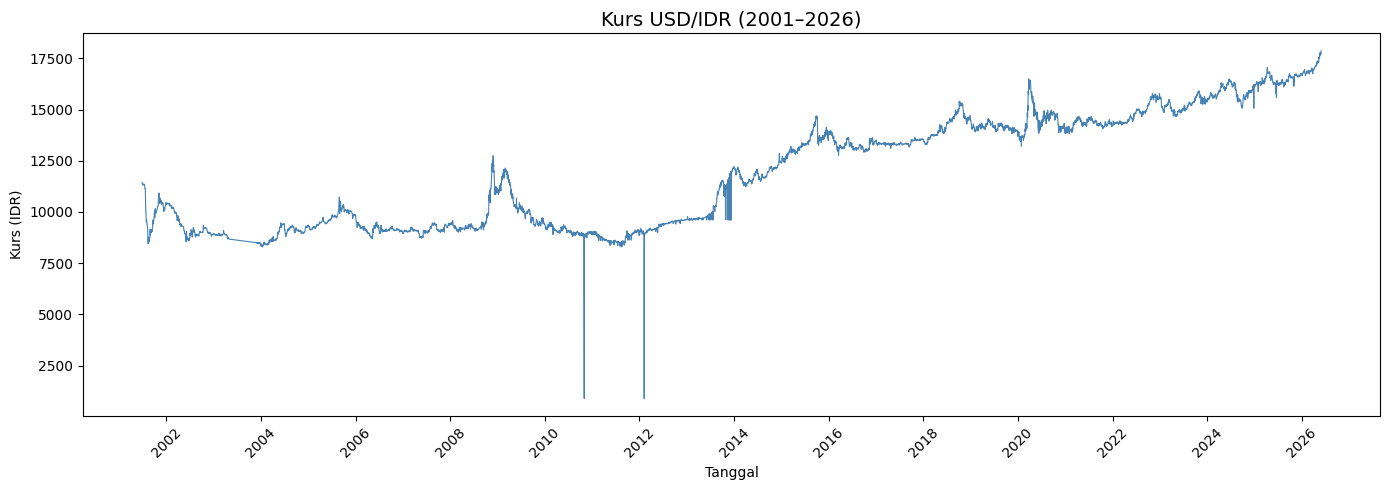

In [12]:
# Cell 2 — Visualisasi historis kurs USD/IDR
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], linewidth=0.8, color='steelblue')
ax.set_title(f'Kurs USD/IDR ({df.index[0].year}–{df.index[-1].year})', fontsize=14)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_historis_kurs_usdidr.png'), dpi=150)
plt.show()

## 2. Feature Engineering

Membangun **22 fitur** (9 teknikal: return, RSI, EMA, volatilitas, dll + 13 fundamental). Fitur fundamental **digeser 1 hari** agar model tidak "mengintip" masa depan (*no lookahead*), dan scaler hanya di-*fit* pada data training (*no leakage*).

**Tambahan fundamental:**
- **US 10Y Treasury Yield** (`^TNX`) — driver utama penguatan USD; yield naik → modal keluar dari EM → IDR melemah.
- **CPO / Palm Oil** (`KCE=F`) — Indonesia eksportir CPO terbesar; harga naik → devisa masuk → IDR menguat.

In [13]:
# Cell 3 — Feature engineering
# Buat 22 fitur: 9 teknikal dan 13 fundamental.
# Semua fitur fundamental digeser 1 hari untuk menghindari lookahead.
# Scaler hanya fit pada data training agar tidak bocor ke test set.

# Array harga raw
data_raw = df['Close'].values.astype(float)
close    = data_raw
high     = df['High'].values.astype(float)
low      = df['Low'].values.astype(float)
N        = len(close)

# Fitur teknikal (9)
close_diff     = np.zeros_like(close)
close_diff[1:] = close[1:] - close[:-1]

returns        = np.zeros_like(close)
returns[1:]    = (close[1:] - close[:-1]) / close[:-1]

hl_range       = (high - low) / close

def compute_rsi(prices, period=14):
    """RSI dengan Wilder's smoothing (alpha = 1/period)."""
    delta    = np.diff(prices, prepend=prices[0])
    gain     = np.where(delta > 0,  delta, 0.0)
    loss     = np.where(delta < 0, -delta, 0.0)
    avg_gain = pd.Series(gain).ewm(alpha=1/period, adjust=False).mean().values
    avg_loss = pd.Series(loss).ewm(alpha=1/period, adjust=False).mean().values
    rs       = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

rsi_14 = compute_rsi(close, period=14)

ema_7         = pd.Series(close).ewm(span=7,  adjust=False).mean().values
ema_21        = pd.Series(close).ewm(span=21, adjust=False).mean().values
ema_7_dev     = (close - ema_7)  / close
ema_21_dev    = (close - ema_21) / close
rolling_std_7 = pd.Series(close).rolling(7).std().fillna(0).values / close

dow   = df.index.dayofweek.values.astype(float)
month = df.index.month.values.astype(float)

# Helper: ekstrak fitur fundamental dari df, shift(1), slice SKIP:
def _fund(col, lag=1):
    """Shift lag hari (hindari lookahead), fillna(0), slice SKIP: sebagai numpy array.
    lag=1  : data pasar harian (DXY, VIX, Brent, IHSG, TNX, CPO)
    lag=30 : data makro bulanan (BI Rate, Fed Rate, CPI) — kompensasi publication lag ~2-4 minggu.
    """
    assert lag <= SKIP, "lag harus <= SKIP agar baris fillna(0) ikut terbuang oleh slice [SKIP:]"
    return df[col].shift(lag).fillna(0).values.astype(float)[SKIP:]

# Susun features_list: 9 teknikal + 13 fundamental
features_list = [
    # --- Teknikal (9) ---
    close_diff[SKIP:],
    returns[SKIP:],
    hl_range[SKIP:],
    rsi_14[SKIP:],
    ema_7_dev[SKIP:],
    ema_21_dev[SKIP:],
    rolling_std_7[SKIP:],
    dow[SKIP:]         / 4.0,
    (month[SKIP:] - 1) / 10.0,
    # --- Fundamental (13) ---
    _fund('dxy_return'),    # DXY return t-1
    _fund('dxy_lag1'),      # DXY return t-2
    _fund('vix_return'),    # VIX return t-1
    _fund('vix_lag1'),      # VIX return t-2
    _fund('brent_return'),  # Brent crude return t-1
    _fund('ihsg_return'),   # IHSG return t-1
    _fund('tnx_return'),    # US 10Y Treasury Yield return t-1
    _fund('cpo_return'),    # CPO (Palm Oil) return t-1
    _fund('bi_rate', lag=30),       # BI Rate (bulanan, ffill) t-1
    _fund('fed_rate', lag=30),      # Fed Funds Rate t-1
    _fund('us_cpi', lag=30),        # US CPI MoM% t-1
    _fund('id_cpi', lag=30),        # ID CPI MoM% t-1
    _fund('rate_spread', lag=30),   # Spread BI-Fed t-1
]

feat_names = [
    'close_diff', 'return', 'hl_range', 'rsi_14',
    'ema_7_dev', 'ema_21_dev', 'rolling_std_7', 'dow', 'month',
    'dxy_ret_t1', 'dxy_ret_t2',
    'vix_ret_t1', 'vix_ret_t2',
    'brent_ret_t1', 'ihsg_ret_t1',
    'tnx_ret_t1', 'cpo_ret_t1',
    'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread',
]

feat       = np.column_stack(features_list)
N_FEATURES = feat.shape[1]

# Split statis (level sequence), dihitung tanpa membuat sequence dulu
# len(X) == n_seq; nilainya sama dengan int(len(X)*0.8) di Cell 4.
n_seq = len(feat) - WINDOW - HORIZON + 1
split = int(n_seq * 0.8)

# Scaler: MaxAbsScaler (nol & tanda terjaga → directional penalty sah)
# fit HANYA pada baris training (hindari data leakage test set).
# Wilayah training = semua baris yang dipakai input window seq training.
fit_rows        = split + WINDOW
feat_scaler     = MaxAbsScaler()
feat_scaler.fit(feat[:fit_rows])
features_scaled = feat_scaler.transform(feat)
target_scaled   = features_scaled[:, 0]

def inverse_close_diff(scaled_arr):
    """Inverse MaxAbsScaler kolom 0: X = X_scaled * scale_[0] (tanpa offset)."""
    arr = np.asarray(scaled_arr).reshape(-1)
    return arr * feat_scaler.scale_[0]

print(f"Fitur input ({N_FEATURES}): {feat_names}")
print(f"Shape features: {features_scaled.shape}  (skip {SKIP} baris warmup)")
print(f"Scaler        : MaxAbsScaler — fit pada {fit_rows} baris training (no leakage)")
print(f"Range close_diff: {close_diff[SKIP:].min():+.1f} s.d. {close_diff[SKIP:].max():+.1f} IDR")

Fitur input (22): ['close_diff', 'return', 'hl_range', 'rsi_14', 'ema_7_dev', 'ema_21_dev', 'rolling_std_7', 'dow', 'month', 'dxy_ret_t1', 'dxy_ret_t2', 'vix_ret_t1', 'vix_ret_t2', 'brent_ret_t1', 'ihsg_ret_t1', 'tnx_ret_t1', 'cpo_ret_t1', 'bi_rate', 'fed_rate', 'us_cpi', 'id_cpi', 'rate_spread']
Shape features: (6260, 22)  (skip 30 baris warmup)
Scaler        : MaxAbsScaler — fit pada 5009 baris training (no leakage)
Range close_diff: -8036.1 s.d. +8038.0 IDR


## 3. Validasi Model — Walk-Forward

Menguji model secara bertahap mengikuti urutan waktu (lebih realistis daripada split acak): tiap *fold* dilatih di data lama lalu diuji di data sesudahnya, dengan scaler di-*refit* per fold.

Walk-Forward Validation  [FAST MODE]  (scaler refit per fold)
  sequences  : 6224  |  init_train : 4356
  step       : 90  |  est. folds : 20
  epochs/fold: 10  (set WF_FAST=False untuk akurasi lebih tinggi)
  Fold  0 | train= 4356 | test= 90 | MAE=  82.20 IDR | DirAcc=49.7%
  Fold  1 | train= 4446 | test= 90 | MAE=  79.32 IDR | DirAcc=50.0%
  Fold  2 | train= 4536 | test= 90 | MAE= 198.21 IDR | DirAcc=50.5%
  Fold  3 | train= 4626 | test= 90 | MAE= 213.57 IDR | DirAcc=50.8%
  Fold  4 | train= 4716 | test= 90 | MAE= 130.66 IDR | DirAcc=50.2%
  Fold  5 | train= 4806 | test= 90 | MAE=  97.66 IDR | DirAcc=49.2%
  Fold  6 | train= 4896 | test= 90 | MAE=  78.46 IDR | DirAcc=50.0%
  Fold  7 | train= 4986 | test= 90 | MAE=  71.93 IDR | DirAcc=48.7%
  Fold  8 | train= 5076 | test= 90 | MAE=  49.91 IDR | DirAcc=50.8%
  Fold  9 | train= 5166 | test= 90 | MAE=  75.03 IDR | DirAcc=50.5%
  Fold 10 | train= 5256 | test= 90 | MAE=  94.42 IDR | DirAcc=46.2%
  Fold 11 | train= 5346 | test= 90 | MAE= 11

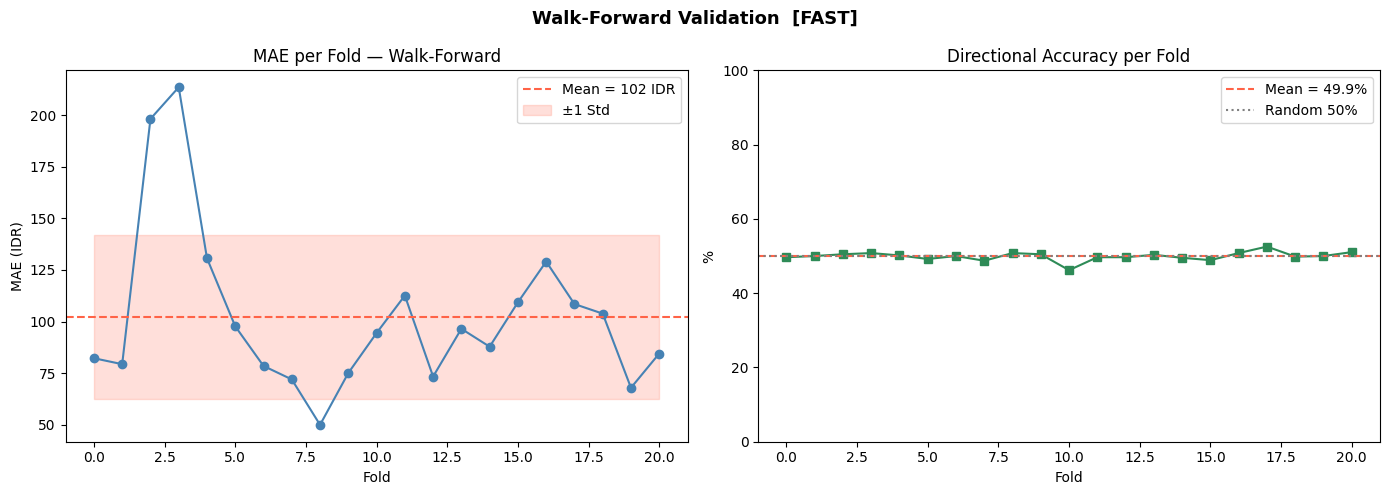

      Metrik              Nilai                             Interpretasi
    Mean MAE         102.12 IDR                  Rata-rata error absolut
     Std MAE 39.92 IDR  (39.1%) TIDAK STABIL ✗  (target: std < 20% mean)
Mean Dir Acc              49.9% Target >60% untuk lebih baik dari random

Split 80/20 untuk Cell 5: X_train=(4979, 30, 22)  X_test=(1245, 30, 22)


In [14]:
# Cell 4 — Buat sequence dan Walk-Forward Validation
# Walk-forward menguji model secara bertahap dalam urutan waktu.
# Setiap fold refit scaler menggunakan hanya data training fold itu.
# Model final tetap dilatih di Cell 5 menggunakan fitur yang telah discale.

# Sliding window sequences ──────────────────────────────────────────────────
def create_sequences(features, target, window, horizon):
    """Sliding window: setiap sample = window hari fitur + horizon hari target."""
    X, y = [], []
    for i in range(window, len(features) - horizon + 1):
        X.append(features[i - window:i])
        y.append(target[i:i + horizon])
    return np.array(X), np.array(y)

# Versi ter-scaling global (untuk model final Cell 5/6/7)
X, y = create_sequences(features_scaled, target_scaled, WINDOW, HORIZON)
# Versi mentah (untuk WF: diskalakan ulang per fold)
X_raw, y_raw = create_sequences(feat, feat[:, 0], WINDOW, HORIZON)

# Loss & arsitektur model — DIDEFINISIKAN SEKALI di sini, dipakai ulang oleh
# Walk-Forward (Cell 4) dan model final (Cell 5).
# Penalti arah valid karena MaxAbsScaler menjaga tanda & titik nol.
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add

def directional_mse_loss(y_true, y_pred, alpha=0.3):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    dir_penalty = tf.reduce_mean(tf.nn.relu(-y_true * y_pred))
    return mse + alpha * dir_penalty

def build_model():
    """LSTM(64) + MultiHeadAttention + LSTM(32) -> Dense(HORIZON), sudah ter-compile."""
    inp  = tf.keras.Input(shape=(WINDOW, N_FEATURES))
    x    = LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.3,
                kernel_regularizer=l2(1e-4))(inp)
    x    = Dropout(0.3)(x)
    attn = MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.1)(x, x)
    x    = LayerNormalization()(Add()([x, attn]))
    x    = LSTM(32, return_sequences=False, dropout=0.2, recurrent_dropout=0.3,
                kernel_regularizer=l2(1e-4))(x)
    x    = Dropout(0.3)(x)
    out  = Dense(HORIZON)(x)
    m    = tf.keras.Model(inp, out)
    m.compile(optimizer='adam', loss=directional_mse_loss)
    return m

# Walk-Forward config ───────────────────────────────────────────────────────
# WF_FAST=True  → step=90, epochs=10  (~20 fold, ~10-20 mnt CPU)
# WF_FAST=False → step=30, epochs=20  (~62 fold, bisa >1 jam CPU)
WF_FAST       = True
WF_INIT_RATIO = 0.70
WF_STEP       = 90 if WF_FAST else 30
WF_EPOCHS     = 10 if WF_FAST else 20

init_train  = int(len(X) * WF_INIT_RATIO)
n_est_fold  = max(1, (len(X) - init_train) // WF_STEP)
print(f"Walk-Forward Validation{'  [FAST MODE]' if WF_FAST else ''}  (scaler refit per fold)")
print(f"  sequences  : {len(X)}  |  init_train : {init_train}")
print(f"  step       : {WF_STEP}  |  est. folds : {n_est_fold}")
print(f"  epochs/fold: {WF_EPOCHS}  (set WF_FAST=False untuk akurasi lebih tinggi)")

fold_records = []
train_end    = init_train

assert WF_STEP >= HORIZON, "WF_STEP harus >= HORIZON agar guard fold tidak membuang semua fold"
while train_end < len(X):
    test_end = min(train_end + WF_STEP, len(X))
    if test_end - train_end == 0:
        break
    if test_end - train_end < HORIZON:   # buang fold terlalu kecil
        break

    # --- RIGOR: refit MaxAbsScaler hanya pada baris training fold ini ---
    # Baris training fold = semua baris yang dipakai input window seq training.
    scaler_fold = MaxAbsScaler().fit(feat[:train_end + WINDOW])
    s_fold      = scaler_fold.scale_                       # (N_FEATURES,), tanpa offset

    X_wf_tr = X_raw[:train_end]          / s_fold          # broadcast per-fitur
    y_wf_tr = y_raw[:train_end]          / s_fold[0]
    X_wf_te = X_raw[train_end:test_end]  / s_fold

    m_wf = build_model()
    m_wf.fit(
        X_wf_tr, y_wf_tr,
        epochs=WF_EPOCHS, batch_size=64, validation_split=0.1,
        callbacks=[EarlyStopping(patience=4, restore_best_weights=True, verbose=0)],
        verbose=0,
    )

    pred_sc = m_wf.predict(X_wf_te, verbose=0)
    sp      = data_raw[SKIP + WINDOW - 1 + train_end :
                       SKIP + WINDOW - 1 + train_end + len(X_wf_te)]
    p_diff  = pred_sc * s_fold[0]                          # inverse → IDR
    t_diff  = y_raw[train_end:test_end]                    # truth sudah IDR mentah
    p_price = sp[:, None] + np.cumsum(p_diff, axis=1)
    t_price = sp[:, None] + np.cumsum(t_diff, axis=1)

    fold_mae = float(np.mean(np.abs(p_price - t_price)))
    fold_dir = float(np.mean(np.sign(p_diff) == np.sign(t_diff))) * 100
    fold_id  = len(fold_records)

    fold_records.append({'fold': fold_id, 'mae': fold_mae, 'dir_acc': fold_dir,
                         'n_train': train_end, 'n_test': len(X_wf_te)})
    print(f"  Fold {fold_id:2d} | train={train_end:5d} | test={len(X_wf_te):3d} "
          f"| MAE={fold_mae:7.2f} IDR | DirAcc={fold_dir:.1f}%")

    train_end += WF_STEP
    del m_wf
    tf.keras.backend.clear_session()

# Hasil agregat ─────────────────────────────────────────────────────────────
wf_df       = pd.DataFrame(fold_records)
mean_mae_wf = wf_df['mae'].mean()
std_mae_wf  = wf_df['mae'].std()
mean_dir_wf = wf_df['dir_acc'].mean()
stable_wf   = bool(std_mae_wf < 0.20 * mean_mae_wf)

print(f"\n{'='*55}")
print(f"  Mean MAE   : {mean_mae_wf:,.2f} IDR")
print(f"  Std MAE    : {std_mae_wf:,.2f} IDR  "
      f"({std_mae_wf / mean_mae_wf * 100:.1f}% dari mean)")
print(f"  Mean Dir   : {mean_dir_wf:.1f}%")
print(f"  Stabilitas : {'STABIL ✓' if stable_wf else 'TIDAK STABIL ✗'}"
      f"  (rule: std < 20% mean)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wf_df['fold'], wf_df['mae'], 'o-', color='steelblue', linewidth=1.5)
axes[0].axhline(mean_mae_wf, color='tomato', linestyle='--',
                label=f'Mean = {mean_mae_wf:.0f} IDR')
axes[0].fill_between(wf_df['fold'],
                     mean_mae_wf - std_mae_wf, mean_mae_wf + std_mae_wf,
                     alpha=0.2, color='tomato', label='±1 Std')
axes[0].set_title('MAE per Fold — Walk-Forward')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('MAE (IDR)')
axes[0].legend()

axes[1].plot(wf_df['fold'], wf_df['dir_acc'], 's-', color='seagreen', linewidth=1.5)
axes[1].axhline(mean_dir_wf, color='tomato', linestyle='--',
                label=f'Mean = {mean_dir_wf:.1f}%')
axes[1].axhline(50, color='gray', linestyle=':', label='Random 50%')
axes[1].set_title('Directional Accuracy per Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend()

plt.suptitle(f'Walk-Forward Validation  {"[FAST]" if WF_FAST else ""}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_walkforward.png'), dpi=150)
plt.show()

print(pd.DataFrame({
    'Metrik'      : ['Mean MAE', 'Std MAE', 'Mean Dir Acc'],
    'Nilai'       : [f"{mean_mae_wf:,.2f} IDR",
                     f"{std_mae_wf:,.2f} IDR  ({std_mae_wf/mean_mae_wf*100:.1f}%)",
                     f"{mean_dir_wf:.1f}%"],
    'Interpretasi': ['Rata-rata error absolut',
                     f"{'STABIL ✓' if stable_wf else 'TIDAK STABIL ✗'}  (target: std < 20% mean)",
                     'Target >60% untuk lebih baik dari random'],
}).to_string(index=False))

# Split statis untuk Cell 5 (pakai global features_scaled, no leakage) ───────
# split sudah dihitung di Cell 3; len(X)*0.8 menghasilkan nilai yang sama.
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print(f"\nSplit 80/20 untuk Cell 5: X_train={X_train.shape}  X_test={X_test.shape}")

## 4. Membangun & Melatih Model

Arsitektur **LSTM + Multi-Head Attention** dengan output langsung 7 hari sekaligus (*direct multi-output*). Loss = MSE + penalti arah, supaya model belajar arah pergerakan (naik/turun), bukan hanya nilai.

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 30, 64)    │     22,272 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 64)    │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 64)    │     16,640 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 32)        │     12,416 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 7)         │        231 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,687 (201.90 KB)

 Trainable params: 51,687 (201.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0310 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0112 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0096 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0083 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0071 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0061 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0053 - val_loss: 0.0040 - learning_rate: 0.0010
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0046 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 9/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0041 - val_loss: 0.0029 - learning_rate:

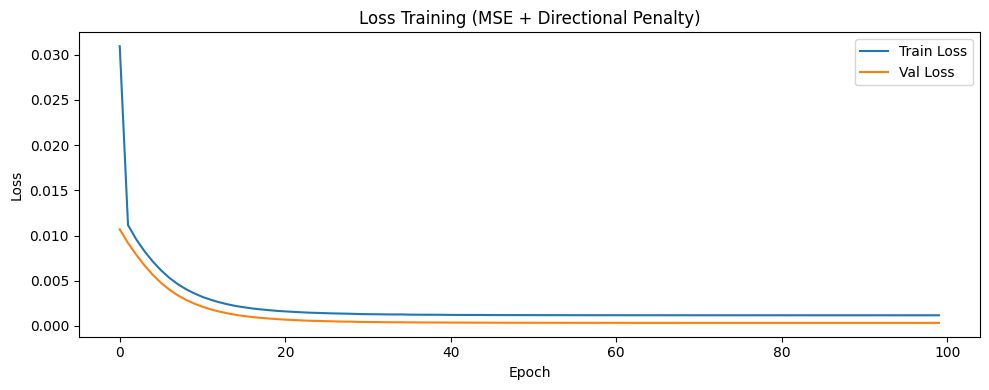

In [15]:
# Cell 5 — Bangun dan latih model
# Arsitektur LSTM + attention untuk prediksi multi-horizon.
# Loss: MSE + penalty arah agar model belajar tren naik/turun.
# directional_mse_loss & build_model didefinisikan di Cell 4, dipakai ulang di sini.

tf.random.set_seed(42)

model = build_model()
model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
]
history = model.fit(
    X_train, y_train,
    epochs=100, batch_size=32, validation_split=0.1,
    callbacks=callbacks, verbose=1,
)

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training (MSE + Directional Penalty)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_loss_training.png'), dpi=150)
plt.show()

## 5. Evaluasi pada Test Set

Mengukur performa pada data yang belum pernah dilihat model: MAE, RMSE, MAPE, *Directional Accuracy*, dan **Theil's U** (U < 1 berarti lebih baik daripada *random walk*).

Test Set — MAE per Hari Horizon:
  Day +1: MAE =   54.81 IDR   RMSE =   91.79 IDR
  Day +2: MAE =   70.66 IDR   RMSE =  107.58 IDR
  Day +3: MAE =   81.06 IDR   RMSE =  118.49 IDR
  Day +4: MAE =   91.66 IDR   RMSE =  130.13 IDR
  Day +5: MAE =  101.37 IDR   RMSE =  140.30 IDR
  Day +6: MAE =  109.88 IDR   RMSE =  150.94 IDR
  Day +7: MAE =  117.64 IDR   RMSE =  159.27 IDR
  Rata-rata: MAE = 89.58 IDR   RMSE = 128.36 IDR


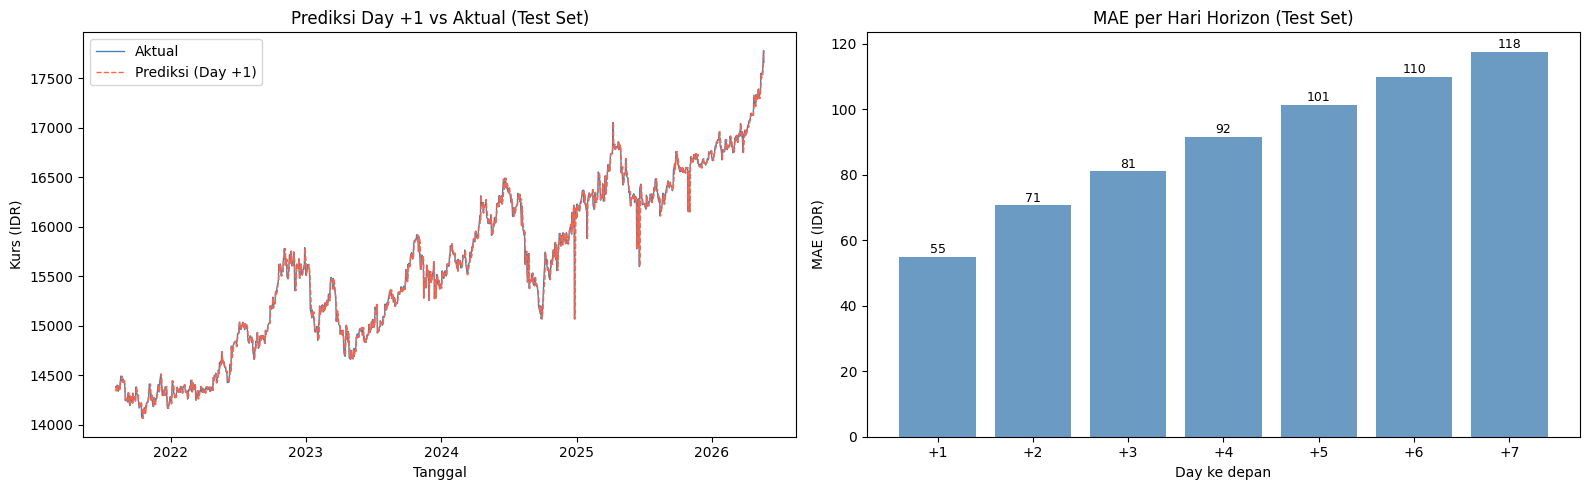

In [16]:
# Cell 6 — Evaluasi pada test set
# Hitung prediksi, inverse scale, dan error per hari horizon.

# Prediksi test set (tanpa dropout)
y_pred_scaled = model.predict(X_test, verbose=0)

# Inverse scaling pada close_diff
y_pred_diff = inverse_close_diff(y_pred_scaled).reshape(y_pred_scaled.shape)
y_true_diff = inverse_close_diff(y_test).reshape(y_test.shape)

# Rekonstruksi harga dari perbedaan harian
# Indexing: feat row j ↔ df row (j + SKIP). Untuk test sample t, "current price" =
# data_raw[SKIP + split + t + WINDOW - 1] (close pada hari terakhir window input).
start_prices = data_raw[SKIP + split + WINDOW - 1 : SKIP + split + WINDOW - 1 + len(y_test)]
y_pred_price = start_prices[:, None] + np.cumsum(y_pred_diff, axis=1)
y_true_price = start_prices[:, None] + np.cumsum(y_true_diff, axis=1)

# Hitung MAE/RMSE per horizon
per_day_mae  = np.mean(np.abs(y_pred_price - y_true_price), axis=0)
per_day_rmse = np.sqrt(np.mean((y_pred_price - y_true_price) ** 2, axis=0))
mae  = float(np.mean(per_day_mae))
rmse = float(np.mean(per_day_rmse))

print("Test Set — MAE per Hari Horizon:")
for d in range(HORIZON):
    print(f"  Day +{d+1}: MAE = {per_day_mae[d]:7.2f} IDR   RMSE = {per_day_rmse[d]:7.2f} IDR")
print(f"  Rata-rata: MAE = {mae:.2f} IDR   RMSE = {rmse:.2f} IDR")

# Plot Day+1 dan error per horizon
test_dates = df.index[SKIP + split + WINDOW : SKIP + split + WINDOW + len(y_test)]
day1_pred  = y_pred_price[:, 0]
day1_true  = y_true_price[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test_dates, day1_true, label='Aktual',            linewidth=1.0, color='steelblue')
axes[0].plot(test_dates, day1_pred, label='Prediksi (Day +1)', linewidth=1.0, color='tomato', linestyle='--')
axes[0].set_title('Prediksi Day +1 vs Aktual (Test Set)')
axes[0].set_xlabel('Tanggal')
axes[0].set_ylabel('Kurs (IDR)')
axes[0].legend()

day_labels = [f'+{i+1}' for i in range(HORIZON)]
bars = axes[1].bar(day_labels, per_day_mae, color='steelblue', alpha=0.8)
axes[1].set_title('MAE per Hari Horizon (Test Set)')
axes[1].set_xlabel('Day ke depan')
axes[1].set_ylabel('MAE (IDR)')
for bar, v in zip(bars, per_day_mae):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + max(per_day_mae) * 0.01,
                 f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_prediksi_vs_aktual_testset.png'), dpi=150)
plt.show()

=== Metrik Evaluasi Profesional — Test Set ===
Day  MAE (IDR)  RMSE (IDR)  MAPE (%)  Dir Acc (%)  Theil's U
 +1      54.81       91.79     0.351         47.4     1.0001
 +2      70.66      107.58     0.452         52.0     1.0001
 +3      81.06      118.49     0.519         53.4     0.9992
 +4      91.66      130.13     0.587         53.5     0.9987
 +5     101.37      140.30     0.649         53.4     0.9982
 +6     109.88      150.94     0.703         53.4     0.9974
 +7     117.64      159.27     0.753         53.5     0.9964

=== Ringkasan ===
             Metrik     Nilai                                                     Interpretasi
      MAE rata-rata 89.58 IDR                                              Error IDR rata-rata
     MAPE rata-rata    0.573%                              Error relatif terhadap harga aktual
  Dir Acc rata-rata     52.4%                                  Ketepatan arah (up/down) harian
Theil's U rata-rata    0.9986 Lebih baik dari naive ✓  (U<1=baik, 

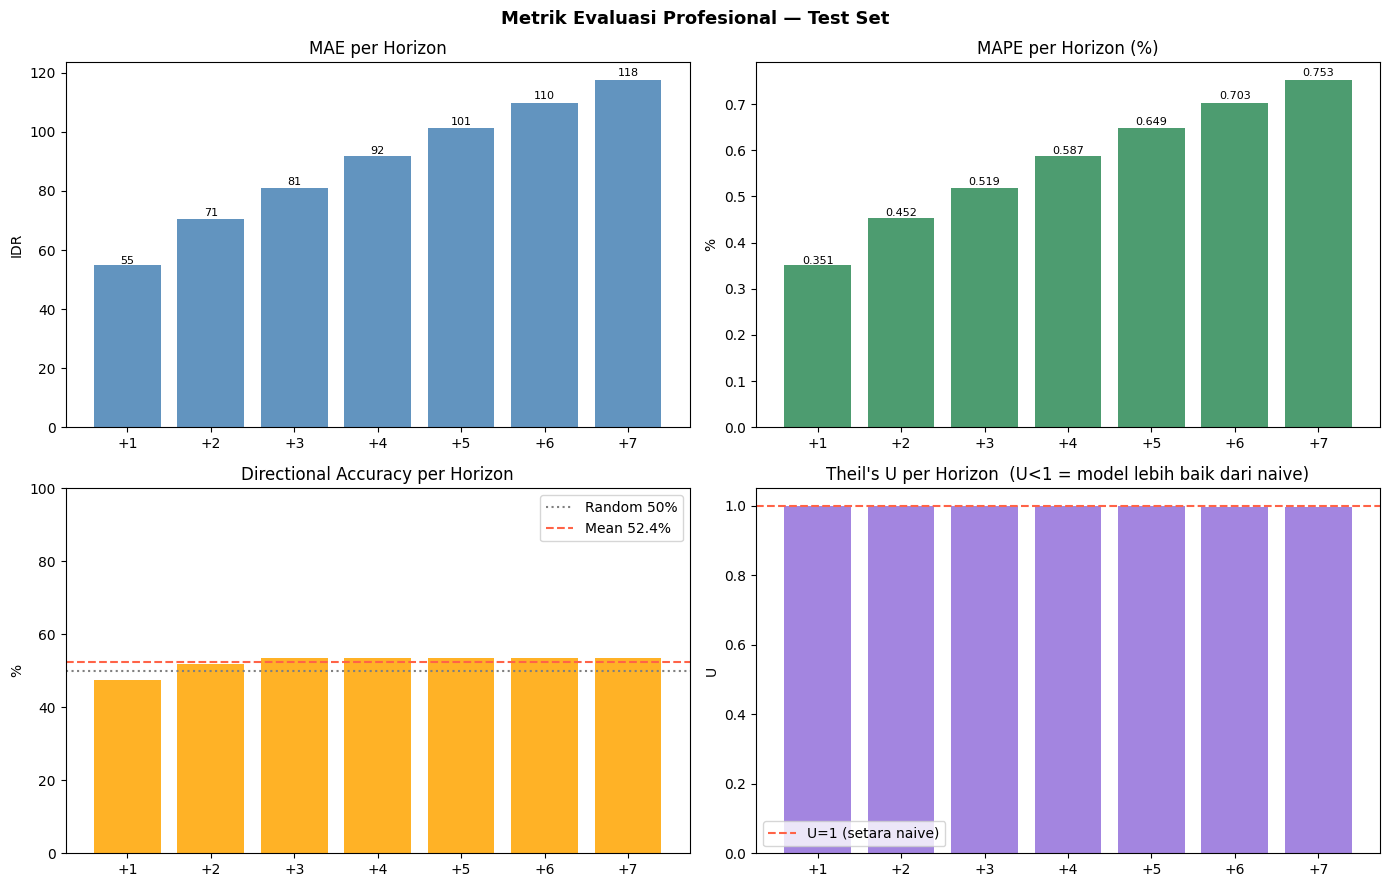

In [17]:
# Cell 6b — Metrik evaluasi profesional
# Hitung MAPE, directional accuracy, dan Theil's U per horizon.
# Dijalankan setelah evaluasi test set di Cell 6.

# MAPE per horizon ──────────────────────────────────────────────────────────
mape_per_day = np.mean(
    np.abs((y_true_price - y_pred_price) / y_true_price) * 100,
    axis=0
)

# Directional Accuracy per horizon ─────────────────────────────────────────
# Arah harian: sign dari close_diff yang diprediksi vs aktual
da_per_day = np.mean(
    np.sign(y_pred_diff) == np.sign(y_true_diff),
    axis=0
) * 100  # shape (HORIZON,)

# Theil's U per horizon ─────────────────────────────────────────────────────
# Naive = random walk: prediksi harga = harga terakhir (start_prices)
# U < 1: lebih baik dari naive | U = 1: setara | U > 1: lebih buruk
naive_price  = np.repeat(start_prices[:, None], HORIZON, axis=1)
theil_u_days = []
for h in range(HORIZON):
    m_rmse = np.sqrt(np.mean((y_pred_price[:, h] - y_true_price[:, h]) ** 2))
    n_rmse = np.sqrt(np.mean((naive_price[:, h]  - y_true_price[:, h]) ** 2))
    theil_u_days.append(float(m_rmse / (n_rmse + 1e-10)))

theil_u_mean = float(np.mean(theil_u_days))  # disimpan untuk Cell 7b

# DataFrame ringkasan per horizon ──────────────────────────────────────────
metrics_pro = pd.DataFrame({
    'Day'         : [f'+{i+1}' for i in range(HORIZON)],
    'MAE (IDR)'   : np.round(per_day_mae,  2),
    'RMSE (IDR)'  : np.round(per_day_rmse, 2),
    'MAPE (%)'    : np.round(mape_per_day, 3),
    'Dir Acc (%)' : np.round(da_per_day,   1),
    "Theil's U"   : np.round(theil_u_days, 4),
})
print("=== Metrik Evaluasi Profesional — Test Set ===")
print(metrics_pro.to_string(index=False))

u_label = ('Lebih baik dari naive ✓' if theil_u_mean < 1
           else 'Setara naive' if abs(theil_u_mean - 1) < 0.01
           else 'Lebih buruk dari naive ✗')
print("\n=== Ringkasan ===")
print(pd.DataFrame({
    'Metrik'       : ['MAE rata-rata', 'MAPE rata-rata',
                      'Dir Acc rata-rata', "Theil's U rata-rata"],
    'Nilai'        : [f"{mae:.2f} IDR", f"{mape_per_day.mean():.3f}%",
                      f"{da_per_day.mean():.1f}%", f"{theil_u_mean:.4f}"],
    'Interpretasi' : ['Error IDR rata-rata',
                      'Error relatif terhadap harga aktual',
                      'Ketepatan arah (up/down) harian',
                      f"{u_label}  (U<1=baik, U=1=setara naive, U>1=buruk)"],
}).to_string(index=False))

# Plot 2×2 ──────────────────────────────────────────────────────────────────
# day_labels sudah didefinisikan di Cell 6
fig, axes  = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(day_labels, per_day_mae,  color='steelblue',    alpha=0.85)
axes[0, 0].set_title('MAE per Horizon'); axes[0, 0].set_ylabel('IDR')
for i, v in enumerate(per_day_mae):
    axes[0, 0].text(i, v * 1.01, f'{v:.0f}', ha='center', fontsize=8)

axes[0, 1].bar(day_labels, mape_per_day, color='seagreen',     alpha=0.85)
axes[0, 1].set_title('MAPE per Horizon (%)'); axes[0, 1].set_ylabel('%')
for i, v in enumerate(mape_per_day):
    axes[0, 1].text(i, v * 1.01, f'{v:.3f}', ha='center', fontsize=8)

axes[1, 0].bar(day_labels, da_per_day,   color='orange',       alpha=0.85)
axes[1, 0].axhline(50, color='gray', linestyle=':', label='Random 50%')
axes[1, 0].axhline(da_per_day.mean(), color='tomato', linestyle='--',
                   label=f'Mean {da_per_day.mean():.1f}%')
axes[1, 0].set_title('Directional Accuracy per Horizon')
axes[1, 0].set_ylabel('%'); axes[1, 0].set_ylim(0, 100); axes[1, 0].legend()

axes[1, 1].bar(day_labels, theil_u_days, color='mediumpurple', alpha=0.85)
axes[1, 1].axhline(1.0, color='tomato', linestyle='--', label="U=1 (setara naive)")
axes[1, 1].set_title("Theil's U per Horizon  (U<1 = model lebih baik dari naive)")
axes[1, 1].set_ylabel('U'); axes[1, 1].legend()

plt.suptitle("Metrik Evaluasi Profesional — Test Set", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_metrics_professional.png'), dpi=150)
plt.show()

## 6. Backtest & Proyeksi 7 Hari ke Depan

*Backtest* dilakukan pada **10 window non-overlapping × 7 hari = 70 hari terakhir** agar directional accuracy tidak bergantung pada 1 window saja. Metrik diagregasi (mean MAE, mean Dir Acc) lebih representatif secara statistik.

Proyeksi 7 hari ke depan menggunakan **Monte Carlo Dropout** untuk mengestimasi rentang ketidakpastian (*confidence interval*).

Melatih model_prod pada seluruh data (100%)...
model_prod selesai — train_loss=0.000964  val_loss=0.000195
=== Backtest 10 Window × 7 Hari (Non-Overlapping) ===
 Window      Start        End  MAE (IDR)  RMSE (IDR)  Dir Acc (%) Arah Benar
      1 2026-05-21 2026-05-29      72.19       80.24         57.1        4/7
      2 2026-05-12 2026-05-20     219.64      246.83         57.1        4/7
      3 2026-05-01 2026-05-11      33.55       36.58         71.4        5/7
      4 2026-04-22 2026-04-30     117.76      134.49         42.9        3/7
      5 2026-04-13 2026-04-21      56.17       60.59         57.1        4/7
      6 2026-04-02 2026-04-10      62.71       71.65         71.4        5/7
      7 2026-03-24 2026-04-01      77.74      107.84         71.4        5/7
      8 2026-03-13 2026-03-23      72.21       82.76         57.1        4/7
      9 2026-03-04 2026-03-12      28.63       34.41         57.1        4/7
     10 2026-02-23 2026-03-03      85.04       93.92         71.4    

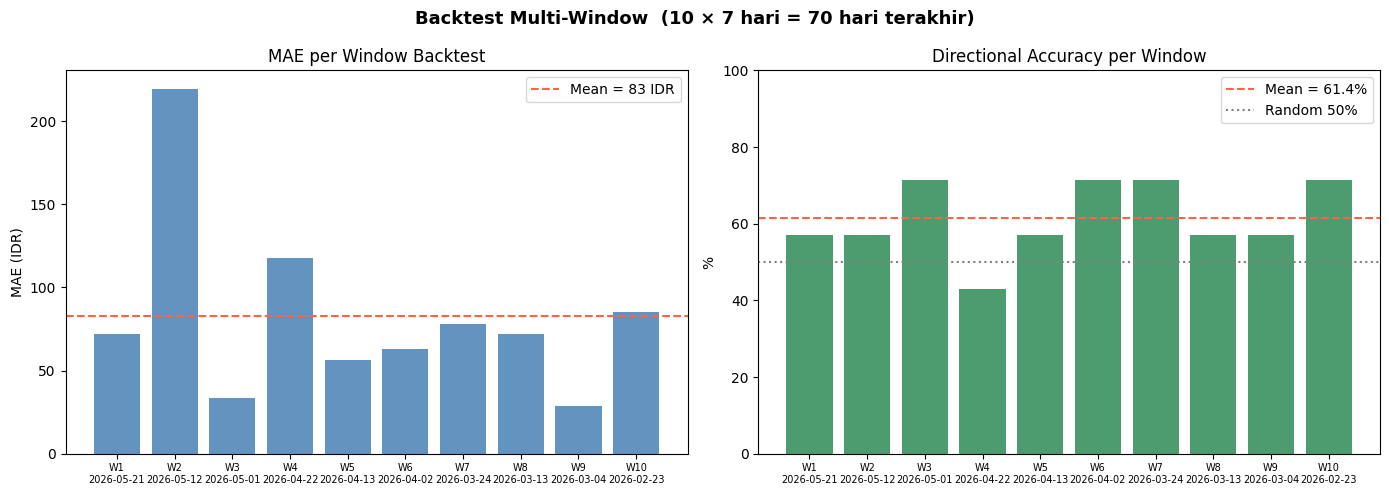

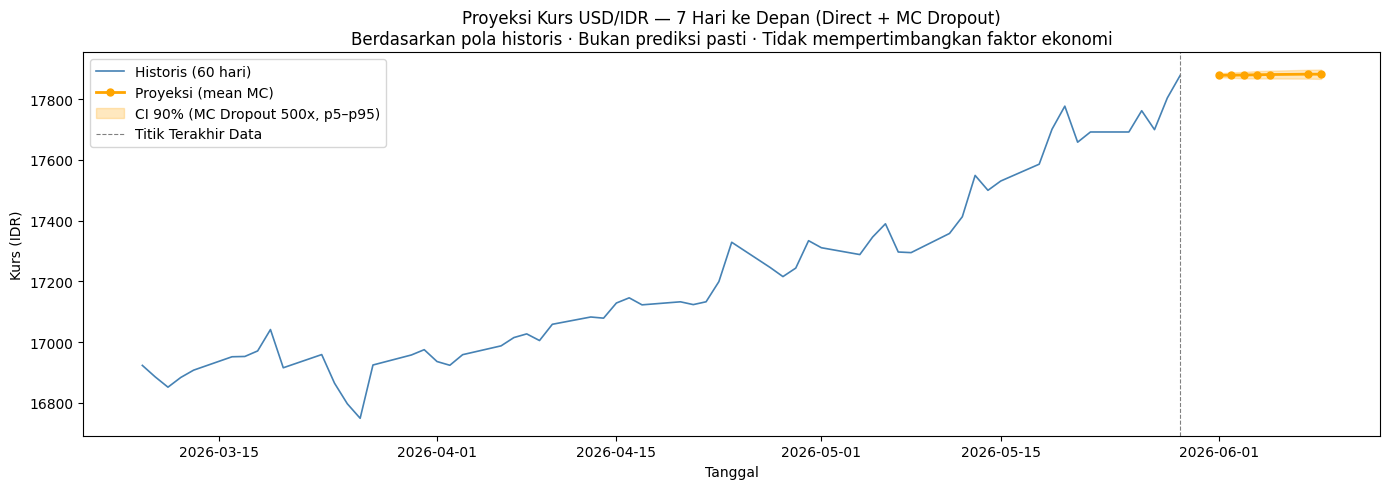


Proyeksi 7 hari ke depan (500 MC samples, CI 5%-95%):
Mean Dir Acc backtest (10 window) : 61.4%

   Tanggal  Proyeksi Kurs (IDR)  CI 5% (IDR)  CI 95% (IDR)  Std (IDR)
2026-06-01                17878        17873         17885          3
2026-06-02                17878        17870         17888          5
2026-06-03                17879        17868         17889          6
2026-06-04                17880        17867         17892          7
2026-06-05                17881        17868         17893          7
2026-06-08                17882        17867         17896          8
2026-06-09                17882        17866         17897          9


In [18]:
# Cell 7 — Backtest multi-window dan proyeksi 7 hari
# Backtest pada N_BT window non-overlapping agar directional accuracy representatif.
# Proyeksi: gunakan MC Dropout untuk estimasi interval ketidakpastian.
#
# model      : dilatih pada X_train (80%) — evaluasi test set (Cell 6) DAN backtest di sini.
#              70 hari backtest = out-of-sample untuk model ini (tidak ikut dilatih).
# model_prod : dilatih pada X_all (100%) — HANYA untuk proyeksi masa depan (hari setelah
#              data terakhir). JANGAN dipakai backtest: 70 hari backtest ada di dalam
#              data fit()-nya sehingga bukan out-of-sample.

# ── Model produksi (refit pada seluruh data) ─────────────────────────────────
print("Melatih model_prod pada seluruh data (100%)...")
tf.random.set_seed(42)
model_prod = build_model()
model_prod.fit(
    X, y,
    epochs=100, batch_size=32, validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, verbose=0),
    ],
    verbose=0,
)
print(f"model_prod selesai — "
      f"train_loss={model_prod.history.history['loss'][-1]:.6f}  "
      f"val_loss={model_prod.history.history['val_loss'][-1]:.6f}")

N_BT = 10  # jumlah window; total: N_BT × HORIZON hari terakhir
M    = len(features_scaled)

# ── Backtest multi-window ─────────────────────────────────────────────────────
bt_all = []
for i in range(N_BT):
    # fs_end = M - (i+1)*HORIZON agar input window berakhir SEBELUM periode actual.
    # Dengan ini: input [fs_start, fs_end) → model prediksi HORIZON hari setelah fs_end,
    # yang tepat adalah periode [actual_start, actual_end).
    fs_end       = M - (i + 1) * HORIZON
    fs_start     = fs_end - WINDOW
    actual_end   = len(data_raw) - i * HORIZON
    actual_start = actual_end - HORIZON

    if fs_start < 0 or actual_start < 0:
        break

    _inp         = features_scaled[fs_start:fs_end].reshape(1, WINDOW, N_FEATURES)
    _start_price = data_raw[actual_start - 1]
    _actual      = data_raw[actual_start:actual_end]
    _dates       = df.index[actual_start:actual_end]

    _pred_scaled = model.predict(_inp, verbose=0)[0]
    _pred_diff   = inverse_close_diff(_pred_scaled)
    _pred_prices = _start_price + np.cumsum(_pred_diff)

    _errors   = np.abs(_pred_prices - _actual)
    _act_dir  = np.sign(np.diff(np.concatenate([[_start_price], _actual])))
    _pred_dir = np.sign(np.diff(np.concatenate([[_start_price], _pred_prices])))
    _dir_corr = int(np.sum(_act_dir == _pred_dir))

    bt_all.append({
        'Window'     : i + 1,
        'Start'      : _dates[0].strftime('%Y-%m-%d'),
        'End'        : _dates[-1].strftime('%Y-%m-%d'),
        'MAE (IDR)'  : round(float(np.mean(_errors)), 2),
        'RMSE (IDR)' : round(float(np.sqrt(np.mean(_errors ** 2))), 2),
        'Dir Acc (%)': round(_dir_corr / HORIZON * 100, 1),
        'Arah Benar' : f'{_dir_corr}/{HORIZON}',
    })

bt_agg_df   = pd.DataFrame(bt_all)
bt_mae_mean = bt_agg_df['MAE (IDR)'].mean()
bt_mae_std  = bt_agg_df['MAE (IDR)'].std()
bt_dir_mean = bt_agg_df['Dir Acc (%)'].mean()

print(f"=== Backtest {N_BT} Window × {HORIZON} Hari (Non-Overlapping) ===")
print(bt_agg_df.to_string(index=False))
print(f"\n{'='*52}")
print(f"  Mean MAE     : {bt_mae_mean:,.2f} IDR  (±{bt_mae_std:.2f})")
print(f"  Mean Dir Acc : {bt_dir_mean:.1f}%  "
      f"({'> 50% ✓' if bt_dir_mean > 50 else '≤ 50% ✗'})")
print(f"  Sample       : {len(bt_agg_df)} window × {HORIZON} hari "
      f"= {len(bt_agg_df) * HORIZON} hari total")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
win_labels = [f"W{r['Window']}\n{r['Start']}" for _, r in bt_agg_df.iterrows()]

axes[0].bar(win_labels, bt_agg_df['MAE (IDR)'], color='steelblue', alpha=0.85)
axes[0].axhline(bt_mae_mean, color='tomato', linestyle='--',
                label=f'Mean = {bt_mae_mean:.0f} IDR')
axes[0].set_title('MAE per Window Backtest')
axes[0].set_ylabel('MAE (IDR)')
axes[0].tick_params(axis='x', labelsize=7)
axes[0].legend()

axes[1].bar(win_labels, bt_agg_df['Dir Acc (%)'], color='seagreen', alpha=0.85)
axes[1].axhline(bt_dir_mean, color='tomato', linestyle='--',
                label=f'Mean = {bt_dir_mean:.1f}%')
axes[1].axhline(50, color='gray', linestyle=':', label='Random 50%')
axes[1].set_title('Directional Accuracy per Window')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', labelsize=7)
axes[1].legend()

plt.suptitle(
    f'Backtest Multi-Window  '
    f'({N_BT} × {HORIZON} hari = {N_BT * HORIZON} hari terakhir)',
    fontweight='bold', fontsize=13,
)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, f'{RUN_TS}_backtest_{HORIZON}hari.png'), dpi=150)
plt.show()

# ── Proyeksi 7 hari via MC Dropout (model_prod) ───────────────────────────────
last_input = features_scaled[-WINDOW:].reshape(1, WINDOW, N_FEATURES)
last_price = data_raw[-1]

mc_batch        = np.repeat(last_input, MC_SAMPLES, axis=0)
mc_preds_scaled = model_prod(mc_batch, training=True).numpy()
mc_preds_diff   = inverse_close_diff(mc_preds_scaled).reshape(MC_SAMPLES, HORIZON)
mc_preds_prices = last_price + np.cumsum(mc_preds_diff, axis=1)

future_mean  = mc_preds_prices.mean(axis=0)
future_p05   = np.percentile(mc_preds_prices, 5,  axis=0)
future_p95   = np.percentile(mc_preds_prices, 95, axis=0)
future_std   = mc_preds_prices.std(axis=0)
future_dates = pd.bdate_range(
    start=df.index[-1] + pd.Timedelta(days=1), periods=HORIZON
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-60:], data_raw[-60:],
        label='Historis (60 hari)', color='steelblue', linewidth=1.2)
ax.plot(future_dates, future_mean,
        label='Proyeksi (mean MC)', color='orange', linewidth=2,
        marker='o', markersize=5)
ax.fill_between(future_dates, future_p05, future_p95,
                color='orange', alpha=0.25,
                label=f'CI 90% (MC Dropout {MC_SAMPLES}x, p5–p95)')
ax.axvline(x=df.index[-1], color='gray', linestyle='--',
           linewidth=0.8, label='Titik Terakhir Data')
ax.set_title(
    f'Proyeksi Kurs USD/IDR — {HORIZON} Hari ke Depan (Direct + MC Dropout)\n'
    f'Berdasarkan pola historis · Bukan prediksi pasti · '
    f'Tidak mempertimbangkan faktor ekonomi'
)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
ax.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, f'{RUN_TS}_proyeksi_{HORIZON}hari_ke_depan.png'), dpi=150
)
plt.show()

pred_df = pd.DataFrame({
    'Tanggal'             : future_dates.strftime('%Y-%m-%d'),
    'Proyeksi Kurs (IDR)' : future_mean.astype(int),
    'CI 5% (IDR)'         : future_p05.astype(int),
    'CI 95% (IDR)'        : future_p95.astype(int),
    'Std (IDR)'           : future_std.astype(int),
})
print(f"\nProyeksi {HORIZON} hari ke depan ({MC_SAMPLES} MC samples, CI 5%-95%):")
print(f"Mean Dir Acc backtest ({N_BT} window) : {bt_dir_mean:.1f}%\n")
print(pred_df.to_string(index=False))

=== Tabel Proyeksi + Confidence Level ===
   Tanggal  Proyeksi Kurs (IDR)  CI 5% (IDR)  CI 95% (IDR)  CI Width (IDR)  Std (IDR) Confidence
2026-06-01                17878        17873         17885              11          3     Tinggi
2026-06-02                17878        17870         17888              17          5     Tinggi
2026-06-03                17879        17868         17889              21          6     Tinggi
2026-06-04                17880        17867         17892              24          7     Tinggi
2026-06-05                17881        17868         17893              25          7     Tinggi
2026-06-08                17882        17867         17896              29          8     Tinggi
2026-06-09                17882        17866         17897              30          9     Tinggi

CATATAN METODOLOGIS
  Theil's U (test set, rata-rata)            : 0.9986  (lebih baik dari random walk ✓)
  Directional acc (backtest 10 window)       : 61.4%  (mean dari 10 window

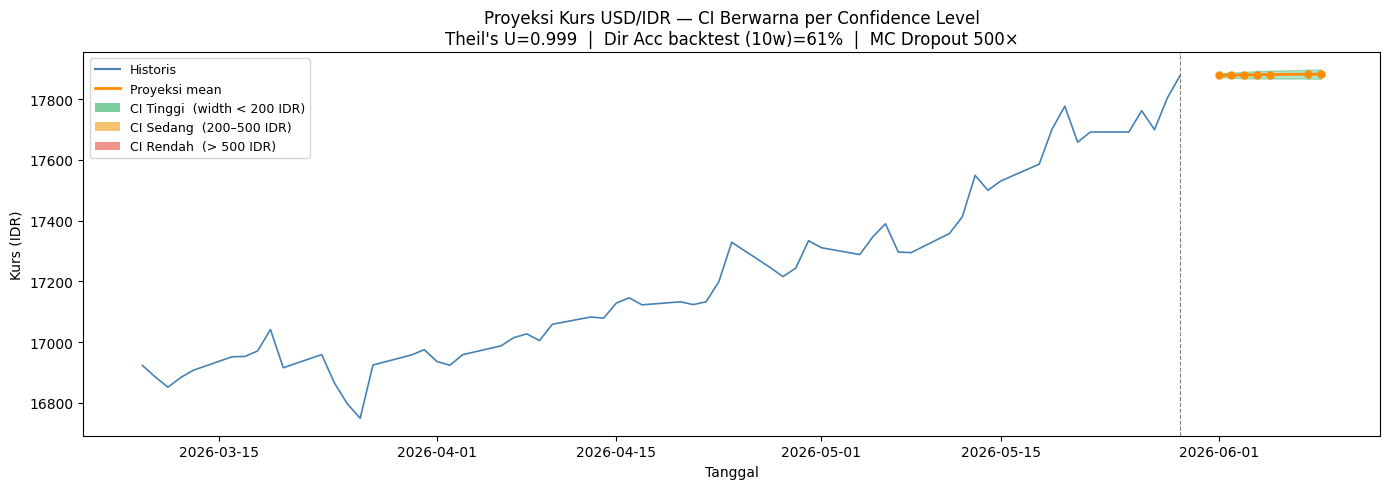

In [19]:
# Cell 7b — Interpretasi confidence interval
# Interpretasi CI setelah proyeksi; tabel proyeksi utama tetap digunakan.
# Memerlukan hasil dari Cell 6b, Cell 7 (bt_agg_df, bt_dir_mean), dan Cell 4 (mean_dir_wf, wf_df).
from matplotlib.patches import Patch

ci_width = future_p95 - future_p05

def _ci_level(width):
    """Kategorikan lebar CI (IDR) ke Tinggi/Sedang/Rendah."""
    if width < 200:   return 'Tinggi'
    elif width < 500: return 'Sedang'
    else:             return 'Rendah'

pred_df_enhanced = pred_df.copy()
pred_df_enhanced.insert(4, 'CI Width (IDR)', ci_width.astype(int))
pred_df_enhanced['Confidence'] = [_ci_level(w) for w in ci_width]

print("=== Tabel Proyeksi + Confidence Level ===")
print(pred_df_enhanced.to_string(index=False))

ci_exp_pct = (ci_width[-1] - ci_width[0]) / (ci_width[0] + 1e-10) * 100
ci_melebar  = bool(ci_exp_pct > 50)

print(f"\n{'='*60}")
print("CATATAN METODOLOGIS")
print(f"{'='*60}")
print(f"  Theil's U (test set, rata-rata)            : {theil_u_mean:.4f}  "
      f"({'lebih baik dari random walk ✓' if theil_u_mean < 1 else 'lebih buruk dari random walk ✗'})")
print(f"  Directional acc (backtest {N_BT} window)       : {bt_dir_mean:.1f}%  "
      f"(mean dari {len(bt_agg_df)} window × {HORIZON} hari)")
print(f"  Directional acc (walk-forward mean)        : {mean_dir_wf:.1f}%  "
      f"({len(wf_df)} fold)")
print(f"  CI Day+1                                   : {ci_width[0]:.0f} IDR  "
      f"[{_ci_level(ci_width[0])}]")
print(f"  CI Day+7                                   : {ci_width[-1]:.0f} IDR  "
      f"[{_ci_level(ci_width[-1])}]")
print(f"  Pelebaran CI D1→D7                         : {ci_exp_pct:.0f}%  "
      f"{'⚠ Melebar signifikan' if ci_melebar else '— Relatif stabil'}")

print("""
┌─────────────────────────────────────────────────────────────────┐
│                     ⚠  PERINGATAN  ⚠                            │
├─────────────────────────────────────────────────────────────────┤
│  PROYEKSI INI BERBASIS POLA HISTORIS.                           │
│                                                                 │
│  Kejadian luar biasa TIDAK DAPAT diprediksi model ini:          │
│  • FOMC surprise (kenaikan/penurunan suku bunga mendadak)      │
│  • Krisis geopolitik & guncangan komoditas global               │
│  • Intervensi Bank Indonesia di pasar valuta asing              │
│  • Sentimen risk-off / risk-on mendadak (flight to safety)      │
│                                                                 │
│  Confidence Interval mencerminkan ketidakpastian MODEL          │
│  (MC Dropout variance), BUKAN ketidakpastian pasar.             │
│  Ketidakpastian pasar nyata bisa jauh lebih besar.              │
│                                                                 │
│  BUKAN REKOMENDASI FINANSIAL.                                   │
└─────────────────────────────────────────────────────────────────┘
""")

_ci_colors = {'Tinggi': '#27ae60', 'Sedang': '#f39c12', 'Rendah': '#e74c3c'}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index[-60:], data_raw[-60:],
        color='steelblue', linewidth=1.2, label='Historis (60 hari)')
ax.plot(future_dates, future_mean,
        color='darkorange', linewidth=2, marker='o', markersize=5,
        label='Proyeksi (mean MC)')

for i in range(len(future_dates) - 1):
    lvl = _ci_level(ci_width[i])
    ax.fill_between(
        [future_dates[i], future_dates[i + 1]],
        [future_p05[i], future_p05[i + 1]],
        [future_p95[i], future_p95[i + 1]],
        color=_ci_colors[lvl], alpha=0.35,
    )

ax.axvline(x=df.index[-1], color='gray', linestyle='--',
           linewidth=0.8, label='Titik terakhir data')

legend_elems = [
    plt.Line2D([0], [0], color='steelblue',  linewidth=1.5, label='Historis'),
    plt.Line2D([0], [0], color='darkorange', linewidth=2,   label='Proyeksi mean'),
    Patch(facecolor='#27ae60', alpha=0.6, label='CI Tinggi  (width < 200 IDR)'),
    Patch(facecolor='#f39c12', alpha=0.6, label='CI Sedang  (200–500 IDR)'),
    Patch(facecolor='#e74c3c', alpha=0.6, label='CI Rendah  (> 500 IDR)'),
]
ax.legend(handles=legend_elems, loc='upper left', fontsize=9)
ax.set_title(
    f"Proyeksi Kurs USD/IDR — CI Berwarna per Confidence Level\n"
    f"Theil's U={theil_u_mean:.3f}  |  "
    f"Dir Acc backtest ({N_BT}w)={bt_dir_mean:.0f}%  |  "
    f"MC Dropout {MC_SAMPLES}×"
)
ax.set_xlabel('Tanggal')
ax.set_ylabel('Kurs (IDR)')
plt.tight_layout()
plt.savefig(
    os.path.join(RESULT_DIR, f'{RUN_TS}_proyeksi_ci_enhanced.png'), dpi=150
)
plt.show()

## 7. Menyimpan Hasil

Menyimpan tabel proyeksi (CSV), ringkasan (TXT), dan seluruh grafik ke folder `Result/<timestamp>/`.

In [20]:
# Cell 8 — Simpan output ke folder Result
# Simpan ringkasan dan tabel proyeksi ke file lokal.

# Simpan tabel proyeksi
csv_path = os.path.join(RESULT_DIR, f'{RUN_TS}_tabel_proyeksi_{HORIZON}hari.csv')
pred_df.to_csv(csv_path, index=False)

# Ringkasan per-hari test set
test_per_day_lines = [
    f"  Day +{d+1}: MAE = {per_day_mae[d]:7.2f} IDR  |  RMSE = {per_day_rmse[d]:7.2f} IDR"
    for d in range(HORIZON)
]

# Ringkasan backtest multi-window
bt_summary_lines = [
    f"  Window {r['Window']:2d} ({r['Start']} s.d. {r['End']}): "
    f"MAE={r['MAE (IDR)']:7.2f} IDR  DirAcc={r['Dir Acc (%)']:.1f}%  ({r['Arah Benar']})"
    for _, r in bt_agg_df.iterrows()
]

summary_lines = [
    f"============================",
    f"  HASIL RUN: {RUN_TS}",
    f"============================",
    f"",
    f"[Data]",
    f"  Sumber         : Yahoo Finance (USDIDR=X)",
    f"  Rentang        : {df.index[0].date()} s.d. {df.index[-1].date()}",
    f"  Total baris    : {len(df)}",
    f"  Close terakhir : {df['Close'].iloc[-1]:,.2f} IDR  ({df.index[-1].date()})",
    f"",
    f"[Fitur Input ({N_FEATURES})]",
    f"  {', '.join(feat_names)}",
    f"",
    f"[Model]",
    f"  Arsitektur     : LSTM(64,d=0.2,rd=0.3,l2) → Dropout(0.3) → MHA(2h,k=32)+LN → LSTM(32,d=0.2,rd=0.3,l2) → Dropout(0.3) → Dense({HORIZON})",
    f"  Loss           : MSE + 0.3 × directional penalty",
    f"  Strategi       : Direct multi-output ({HORIZON} hari sekaligus, bukan autoregressive)",
    f"  Window         : {WINDOW} hari",
    f"  Skip warmup    : {SKIP} hari",
    f"  Split          : 80% train / 20% test",
    f"  Epochs run     : {len(history.history['loss'])}",
    f"  Train Loss     : {history.history['loss'][-1]:.6f}",
    f"  Val Loss       : {history.history['val_loss'][-1]:.6f}",
    f"  Model evaluasi : model 80% (test set + backtest, out-of-sample)",
    f"  Model proyeksi : model_prod 100% (refit seluruh data; khusus proyeksi masa depan)",
    f"",
    f"[Test Set — MAE per Hari Horizon]",
    *test_per_day_lines,
    f"  Rata-rata: MAE = {mae:.2f} IDR  |  RMSE = {rmse:.2f} IDR",
    f"",
    f"[Backtest Multi-Window ({N_BT} × {HORIZON} Hari = {N_BT * HORIZON} Hari Terakhir)]",
    *bt_summary_lines,
    f"  Mean MAE     : {bt_mae_mean:,.2f} IDR  (±{bt_mae_std:.2f})",
    f"  Mean Dir Acc : {bt_dir_mean:.1f}%  "
    f"({'> 50% ✓' if bt_dir_mean > 50 else '≤ 50% ✗'})",
    f"",
    f"[Proyeksi {HORIZON} Hari ke Depan — MC Dropout {MC_SAMPLES}x, CI 5%-95%]",
    pred_df.to_string(index=False),
    f"",
    f"[Kesimpulan]",
    f"  Model LSTM direct multi-output dengan {N_FEATURES} fitur input",
    f"  ({', '.join(feat_names)})",
    f"  memprediksi {HORIZON} hari sekaligus, bukan autoregressive,",
    f"  sehingga error tidak terakumulasi antar hari.",
    f"  Loss training menggabungkan MSE dan penalty arah (alpha=0.3)",
    f"  untuk memaksa model belajar arah pergerakan.",
    f"  Backtest multi-window ({N_BT} × {HORIZON} hari): mean Dir Acc = {bt_dir_mean:.1f}%.",
    f"  Confidence interval dihitung via Monte Carlo Dropout ({MC_SAMPLES} samples)",
    f"  dengan dropout aktif pada input, recurrent, dan hidden state LSTM.",
    f"",
    f"[Keterbatasan Model]",
    f"  - Menggunakan {N_FEATURES} fitur teknikal & fundamental; tidak dapat memprediksi",
    f"    kejadian luar biasa (FOMC surprise, krisis geopolitik, intervensi BI mendadak)",
    f"  - Proyeksi ini BUKAN rekomendasi finansial",
    f"  - Model cenderung mengikuti tren historis (kurs naik jangka panjang)",
    f"  - MC Dropout CI mencerminkan ketidakpastian MODEL, bukan ketidakpastian PASAR",
    f"    (ketidakpastian pasar nyata bisa jauh lebih besar)",
    f"  - Akurasi menurun signifikan jika terjadi peristiwa ekonomi tak terduga",
    f"",
    f"[File Output]",
    f"  {RUN_TS}_historis_kurs_usdidr.png",
    f"  {RUN_TS}_walkforward.png",
    f"  {RUN_TS}_loss_training.png",
    f"  {RUN_TS}_prediksi_vs_aktual_testset.png",
    f"  {RUN_TS}_metrics_professional.png",
    f"  {RUN_TS}_backtest_{HORIZON}hari.png",
    f"  {RUN_TS}_proyeksi_{HORIZON}hari_ke_depan.png",
    f"  {RUN_TS}_proyeksi_ci_enhanced.png",
    f"  {RUN_TS}_tabel_proyeksi_{HORIZON}hari.csv",
    f"  {RUN_TS}_summary.txt",
]

txt_path = os.path.join(RESULT_DIR, f'{RUN_TS}_summary.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(summary_lines))

print('\n'.join(summary_lines))
print(f"\nSemua output tersimpan di:\n  {RESULT_DIR}")

  HASIL RUN: 20260530_145935

[Data]
  Sumber         : Yahoo Finance (USDIDR=X)
  Rentang        : 2001-06-28 s.d. 2026-05-29
  Total baris    : 6290
  Close terakhir : 17,878.00 IDR  (2026-05-29)

[Fitur Input (22)]
  close_diff, return, hl_range, rsi_14, ema_7_dev, ema_21_dev, rolling_std_7, dow, month, dxy_ret_t1, dxy_ret_t2, vix_ret_t1, vix_ret_t2, brent_ret_t1, ihsg_ret_t1, tnx_ret_t1, cpo_ret_t1, bi_rate, fed_rate, us_cpi, id_cpi, rate_spread

[Model]
  Arsitektur     : LSTM(64,d=0.2,rd=0.3,l2) → Dropout(0.3) → MHA(2h,k=32)+LN → LSTM(32,d=0.2,rd=0.3,l2) → Dropout(0.3) → Dense(7)
  Loss           : MSE + 0.3 × directional penalty
  Strategi       : Direct multi-output (7 hari sekaligus, bukan autoregressive)
  Window         : 30 hari
  Skip warmup    : 30 hari
  Split          : 80% train / 20% test
  Epochs run     : 100
  Train Loss     : 0.001173
  Val Loss       : 0.000331
  Model evaluasi : model 80% (test set + backtest, out-of-sample)
  Model proyeksi : model_prod 100% (r